# Reading a FRET distance network as a picture

A single FRET measurement is one distance between two labelled positions. A
*network* is many of them on the same molecule: ten, twenty, sometimes a
hundred pairs of sites, each with its own donor, its own acceptor, its own
uncertainty. The network is what turns FRET from a ruler into a structural
method, because no single distance pins a structure and twenty of them, spread
over the molecule, can.

The problem is reading one. A network of seventeen pairs is a table of
seventeen rows of measured distance, modelled distance, difference and
uncertainty. A table is fine for looking up one number and useless for the
question you actually have, which is *where* the model and the measurements
disagree. Is the disagreement everywhere, which means the model is simply the
wrong state? Is it in one domain, which means that domain is placed wrong? Is
it on the chords that touch one particular site, which usually means that
site's label is behaving badly and the model is innocent?

The **circle plot** answers that question by putting geometry back into the
picture:

* every labelled **site** is a point on the rim, ordered so that sites that
  belong together sit together -- here, by domain;
* every **measured pair** is a chord between its two sites;
* the **colour** of the chord is the signed deviation, modelled minus measured,
  in Angstrom: red where the model is too long, blue where it is too short,
  pale where it agrees;
* the **thickness** of the chord is the same deviation measured in standard
  deviations of the experiment -- how *significant* the disagreement is, not
  how large it is in Angstrom.

Colour and thickness deliberately carry different things. A 10 A miss on a pair
measured to +-15 A is pale-ish and thin; a 4 A miss on a pair measured to +-1 A
is pale and thick. The eye picks out the thick chords, which are the ones worth
arguing about.

What this notebook does: build a seventeen-pair network on hGBP1, score the two
ends of its recorded conformational transition against it, and then look at the
same numbers three ways -- as a table, as a circle, and as a scatter. Along the
way it does something a workshop notebook usually skips: it takes the *real*
measured hGBP1 network that ships with `IMP.bff`, tries to use it, and explains
precisely why it cannot be used against this structure.

## Setup

`workshop.py` next to this notebook holds the pieces every notebook in this
series shares: the hGBP1 transition and its frames, the accessible-volume call
with the dye geometries filled in, the published FRET network, and the circle
plot itself. Everything is read from the checkout, so this runs offline.

In [1]:
%matplotlib inline
import collections
import itertools
import pathlib
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

here = pathlib.Path.cwd()
for candidate in (here, here / "doc" / "workshop", here.parent):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate))
        break
import workshop as ws

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3})

t_start = time.time()
n_frames = ws.hgbp1_n_frames()
LAST = n_frames - 1
start = ws.hgbp1_state(0)
end = ws.hgbp1_state(LAST)
print("hGBP1's recorded open/closed transition: %d frames" % n_frames)
print("  frame  0 -> %s" % start.name)
print("  frame %2d -> %s" % (LAST, end.name))
print("Forster radius of the Alexa488/Alexa647 pair, R0 =", ws.R0, "A")

residues = collections.defaultdict(list)
for line in start.read_text().splitlines():
    if line.startswith("ATOM") and line[12:16].strip() == "CA":
        residues[line[21]].append(int(line[22:26]))
total = sum(len(v) for v in residues.values())
print("topology: %d residues in chains %s -- chain A is residues %d-%d and chain B is %d-%d,"
      % (total, "/".join(sorted(residues)),
         min(residues["A"]), max(residues["A"]),
         min(residues["B"]), max(residues["B"])))
print("          which are two *ranges of one molecule*, not two protein copies.")

hGBP1's recorded open/closed transition: 58 frames
  frame  0 -> hGBP1_frame000.pdb
  frame 57 -> hGBP1_frame057.pdb
Forster radius of the Alexa488/Alexa647 pair, R0 = 52.0 A
topology: 570 residues in chains A/B -- chain A is residues 1-151 and chain B is 152-570,
          which are two *ranges of one molecule*, not two protein copies.


### The molecule, moving

The two states this notebook scores are the two ends of the path below. Watch
it once: the change is a hinge between the globular GTPase domain and the long
C-terminal helices, and every distance in the network is a different projection
of that one motion.

In [2]:
frames = ws.hgbp1_frames(every=6)
ws.show([{"title": "hGBP1: the recorded transition, every 6th frame",
          "structure": ws.morph_pdb(frames), "animate_models": True,
          "frame_ms": 320, "clouds": []}], height=420)

## The measured network, and why it cannot be used here

`IMP.bff` ships a real, published hGBP1 FRET network: `ws.hgbp1_network()`
reads the `fps.json` in `examples/structure/GBP`. Unlike everything else in
this workshop it is not invented. Before inventing anything, it is worth asking
whether it can be used, and the answer is instructive.

In [3]:
network = ws.hgbp1_network()
print("positions           %d" % len(network["positions"]))
print("distance entries    %d" % len(network["distances"]))
print("chi2 sets declared  %s" % ", ".join(network["chi2_sets"]))

places = network["positions"]
unique = {}
for name, entry in network["distances"].items():
    a = places[entry["position1_name"]]["residue_seq_number"]
    b = places[entry["position2_name"]]["residue_seq_number"]
    unique.setdefault((min(a, b), max(a, b)), (name, entry))
print("distinct measurements %d  (hGBP1 is a C2-symmetric homodimer, so the file"
      % len(unique))
print("                         declares every measurement twice, once per protomer)")

kinds = collections.Counter(e["distance_type"] for _, e in unique.values())
radii = collections.Counter(e["Forster_radius"] for _, e in unique.values())
print("distance type       %s" % dict(kinds))
print("Forster radius      %s A" % dict(radii))

print()
print("the labelling positions the network declares:")
by_chain = collections.defaultdict(list)
for name, position in network["positions"].items():
    by_chain[position["chain_identifier"]].append(
        (position["residue_seq_number"], name))
for chain in sorted(by_chain):
    listing = ", ".join("%s(%d)" % (n, r) for r, n in sorted(by_chain[chain]))
    print("  protomer %s: %s" % (chain, listing))

positions           18
distance entries    68
chi2 sets declared  577_577, inter
distinct measurements 34  (hGBP1 is a C2-symmetric homodimer, so the file
                         declares every measurement twice, once per protomer)
distance type       {'RDAMean': 34}
Forster radius      {52: 34} A

the labelling positions the network declares:
  protomer A: A18F(18), A254F(254), A344F(344), A481F(481), A496F(496), A525F(525), A540F(540), A577F(577), A577F_eGFP(825)
  protomer B: B18F(18), B254F(254), B344F(344), B481F(481), B496F(496), B525F(525), B540F(540), B577F(577), A577F_mCh(815)


In [4]:
# Does any of it land on the structure we have?
topology_residues = {chain: set(v) for chain, v in residues.items()}
chain_of = lambda resi: "A" if resi <= 151 else "B"

label_residues = sorted({p["residue_seq_number"] for p in network["positions"].values()})
print("residue   in this topology?")
usable = []
for resi in label_residues:
    chain = chain_of(resi)
    present = resi in topology_residues.get(chain, ())
    if present:
        usable.append(resi)
    print("  %4d    %s" % (resi, ("yes, as chain %s residue %d" % (chain, resi))
                           if present else "no -- the model stops at residue %d"
                           % max(max(v) for v in topology_residues.values())))
print()
print("%d of the %d labelled residues exist in this topology: %s"
      % (len(usable), len(label_residues), usable))

residue   in this topology?
    18    yes, as chain A residue 18
   254    yes, as chain B residue 254
   344    yes, as chain B residue 344
   481    yes, as chain B residue 481
   496    yes, as chain B residue 496
   525    yes, as chain B residue 525
   540    yes, as chain B residue 540
   577    no -- the model stops at residue 570
   815    no -- the model stops at residue 570
   825    no -- the model stops at residue 570

7 of the 10 labelled residues exist in this topology: [18, 254, 344, 481, 496, 525, 540]


In [5]:
# The trap: a measured pair and a modelled pair can carry the same two residue
# numbers and mean completely different things. Every measured distance in this
# file is inter-protomer -- donor on one copy of hGBP1, acceptor on the other.
# This topology has one copy.
cross = collections.Counter()
for _, entry in unique.values():
    a = network["positions"][entry["position1_name"]]["chain_identifier"]
    b = network["positions"][entry["position2_name"]]["chain_identifier"]
    cross["inter-protomer" if a != b else "intra-protomer"] += 1
print("measured distances by kind: %s" % dict(cross))
print()

# For the pairs whose two residue numbers both exist here, compare the measured
# inter-protomer value with what the single molecule can offer over its whole
# trajectory.
print("measured pair          measured        the same two residue numbers within")
print("                                       one molecule, over all %d frames" % n_frames)
print("-" * 76)
comparison = []
same_residue = 0
for name, entry in sorted(unique.values(), key=lambda pair: pair[0]):
    p1 = network["positions"][entry["position1_name"]]
    p2 = network["positions"][entry["position2_name"]]
    a, b = p1["residue_seq_number"], p2["residue_seq_number"]
    if a == b:
        same_residue += 1
        continue
    if a not in usable or b not in usable:
        continue
    span = []
    for frame in range(0, n_frames, 8):
        pdb = ws.hgbp1_state(frame)
        span.append(ws.rda(ws.av(pdb, chain_of(a), a, "Alexa488"),
                           ws.av(pdb, chain_of(b), b, "Alexa647")))
    comparison.append((name, entry["distance"], min(span), max(span)))
    print("  %-18s %7.1f +- %-4.1f     %5.1f to %5.1f A"
          % (name, entry["distance"], entry["error_pos"], min(span), max(span)))

outside = [c for c in comparison if c[1] < c[2] or c[1] > c[3]]
print()
print("%d of these %d measured values lie outside the entire range the single"
      % (len(outside), len(comparison)))
print("molecule can produce for the same two residue numbers.")
print("%d further measured pairs carry the *same* residue on both protomers and"
      % same_residue)
print("have no single-molecule counterpart at all.")

measured distances by kind: {'inter-protomer': 34}

measured pair          measured        the same two residue numbers within
                                       one molecule, over all 58 frames
----------------------------------------------------------------------------


  A18F-B254F           105.5 +- 8.2       48.2 to  54.4 A


  A18F-B344F            55.4 +- 2.5       36.9 to  64.0 A
  A18F-B481F            75.8 +- 7.3       80.5 to  91.0 A


  A18F-B496F            78.6 +- 2.3       59.0 to  77.5 A


  A18F-B525F            60.9 +- 5.0       23.8 to  56.7 A
  A18F-B540F            66.0 +- 3.6       27.4 to  63.2 A


...

  A344F-B525F           62.2 +- 2.1       32.9 to  51.0 A
  A344F-B540F           70.7 +- 8.2       50.8 to  71.0 A


  A481F-B496F           45.8 +- 5.4       27.4 to  32.8 A


  A481F-B525F           73.9 +- 8.0       66.3 to  70.9 A
  A481F-B540F           79.0 +- 8.9       86.6 to  94.5 A


  A496F-B525F           51.1 +- 2.3       46.1 to  51.0 A


  A496F-B540F           69.0 +- 3.0       65.5 to  71.2 A

14 of these 20 measured values lie outside the entire range the single
molecule can produce for the same two residue numbers.
7 further measured pairs carry the *same* residue on both protomers and
have no single-molecule counterpart at all.


That settles it, and the sentence is worth as much as any figure below.

**The measured hGBP1 network cannot be scored against this topology.** Three
reasons, in increasing order of how badly they bite:

1. One of the eight labelled residues, 577, does not exist in the model at all:
   the recorded trajectory covers 570 residues.
2. The network's `577_577` set is not a protein-protein distance at all -- it is
   an eGFP/mCherry pair on positions numbered 825 and 815, a fluorescent-protein
   construct, with no counterpart anywhere in a backbone model.
3. Every single measured distance is **inter-protomer**: donor on one copy of
   hGBP1, acceptor on the other copy, in the dimer. This topology is one copy.
   Its chains A and B are residue ranges of a single molecule, so a pair of
   residue numbers that appears in both lists means two different things in the
   two places -- and the numbers prove it. For most of the pairs whose two
   residue numbers both exist here, the measured value sits outside the entire
   range one molecule can produce for them at any point along its transition.
   The seven measurements made between the *same* residue on the two protomers
   have no single-molecule counterpart at all: within one copy that is a
   distance from a residue to itself.

The third point is the one that would survive a careless renumbering, and it is
the one that would silently ruin an analysis. A chi-squared can be computed
from any two lists of the same length. Nothing in the arithmetic knows that one
list is about a dimer interface and the other about the inside of a monomer.

So the measurements below are **synthetic**, and the rest of this section says
exactly what that buys and what it hides. What is *not* synthetic: the seven
labelling positions are the published ones, the dye geometries are the ones the
published file declares, R0 = 52 A is the published value, and the two
structures are the two ends of a recorded transition.

## The network we can build

Seven labelling positions, and every pair of them whose modelled distance stays
inside the range a FRET measurement is actually informative over -- roughly
`0.5 * R0` to `1.5 * R0`, 26 to 78 A here -- across the whole trajectory. Below
that, efficiency saturates near 1; above it, efficiency is flat and the error
bar on a distance explodes. A pair that leaves the window somewhere along the
path would be a pair whose model can be scored on some frames and not on
others, which is not a network you want to compare across states.

The sites are grouped on the rim by hGBP1's conventional domain boundaries: the
globular LG (GTPase) domain up to residue 278, the middle domain to 481, and
the long C-terminal helices alpha-12/13 beyond that.

In [6]:
LABEL_SITES = [18, 254, 344, 481, 496, 525, 540]
DONOR_DYE, ACCEPTOR_DYE = "Alexa488", "Alexa647"


def domain(resi):
    if resi <= 278:
        return "LG domain"
    if resi <= 481:
        return "middle"
    return "alpha-12/13"


def site_label(resi):
    return "%s%d" % (chain_of(resi), resi)


t0 = time.time()
volumes = {}
for frame in range(n_frames):
    pdb = ws.hgbp1_state(frame)
    volumes[frame] = {(resi, dye): ws.av(pdb, chain_of(resi), resi, dye)
                      for resi in LABEL_SITES
                      for dye in (DONOR_DYE, ACCEPTOR_DYE)}
print("%d accessible volumes over %d frames in %.1f s"
      % (len(LABEL_SITES) * 2 * n_frames, n_frames, time.time() - t0))


def network_of(frame, pairs):
    av = volumes[frame]
    return {p: ws.rda_e(av[(p[0], DONOR_DYE)], av[(p[1], ACCEPTOR_DYE)]) for p in pairs}


candidates = list(itertools.combinations(LABEL_SITES, 2))
track = {p: np.array([ws.rda_e(volumes[f][(p[0], DONOR_DYE)],
                               volumes[f][(p[1], ACCEPTOR_DYE)])
                      for f in range(n_frames)]) for p in candidates}
LO, HI = 0.5 * ws.R0, 1.5 * ws.R0
PAIRS = [p for p in candidates if track[p].min() >= LO and track[p].max() <= HI]
dropped = [p for p in candidates if p not in PAIRS]

print("%d of %d possible pairs stay inside %.0f-%.0f A over the whole path"
      % (len(PAIRS), len(candidates), LO, HI))
for p in dropped:
    print("  dropped %3d-%-3d : %5.1f to %5.1f A" % (p[0], p[1], track[p].min(), track[p].max()))

SITES = [s for s in LABEL_SITES if any(s in p for p in PAIRS)]
GROUPS = {s: domain(s) for s in SITES}
ORDER = sorted(SITES)
print()
for name in ("LG domain", "middle", "alpha-12/13"):
    members = [site_label(s) for s in SITES if GROUPS[s] == name]
    print("  %-12s %s" % (name + ":", ", ".join(members)))

812 accessible volumes over 58 frames in 3.4 s


17 of 21 possible pairs stay inside 26-78 A over the whole path
  dropped  18-481 :  75.8 to  91.9 A
  dropped 254-481 :  69.7 to 117.4 A
  dropped 254-496 :  53.5 to 100.8 A
  dropped 481-540 :  81.7 to  90.8 A

  LG domain:   A18, B254
  middle:      B344, B481
  alpha-12/13: B496, B525, B540


### The modelled distances

For every site the accessible volume of its dye is computed on the structure,
and for every pair the two volumes are reduced to one number: `<R_DA>_E`, the
distance that reproduces the mean transfer efficiency of the pair. It is not
the mean of the distance distribution -- notebook 3 measures the gap between
the two, which runs to several Angstrom -- and `<R_DA>_E` is what an efficiency
measurement reports.

In [7]:
d_start = network_of(0, PAIRS)
d_end = network_of(LAST, PAIRS)

print("%14s  %8s  %8s  %12s" % ("pair", "frame 0", "frame %d" % LAST, "difference"))
print("-" * 50)
for p in PAIRS:
    name = "%s-%s" % (site_label(p[0]), site_label(p[1]))
    print("%14s  %8.1f  %8.1f  %+12.1f" % (name, d_start[p], d_end[p], d_end[p] - d_start[p]))
print()
movers = sorted(PAIRS, key=lambda p: -abs(d_end[p] - d_start[p]))
print("the pairs that carry the state change: %s"
      % ", ".join("%s-%s (%+.0f A)" % (site_label(p[0]), site_label(p[1]),
                                       d_end[p] - d_start[p]) for p in movers[:4]))
print("the pairs that carry none of it:       %s"
      % ", ".join("%s-%s (%+.0f A)" % (site_label(p[0]), site_label(p[1]),
                                       d_end[p] - d_start[p]) for p in movers[-4:]))

          pair   frame 0  frame 57    difference
--------------------------------------------------
      A18-B254      49.8      53.3          +3.4
      A18-B344      45.8      41.6          -4.3
      A18-B496      72.4      58.0         -14.4
      A18-B525      55.1      32.3         -22.8
      A18-B540      61.0      33.4         -27.7
     B254-B344      69.5      62.6          -6.9
     B254-B525      60.8      46.2         -14.7
     B254-B540      58.2      50.7          -7.5
     B344-B481      55.4      54.4          -1.1
     B344-B496      49.2      40.7          -8.5
     B344-B525      50.8      36.1         -14.7
     B344-B540      67.3      52.0         -15.3
     B481-B496      34.5      35.1          +0.6
     B481-B525      65.2      67.2          +2.0
     B496-B525      49.5      49.1          -0.4
     B496-B540      67.1      67.5          +0.4
     B525-B540      35.9      35.2          -0.7

the pairs that carry the state change: A18-B540 (-28 A), A18-B525 

### The sites on the structure

The rim of a circle plot is an abstraction of this. Both ends of the
transition, with the accessible volume of every one of the seven positions
drawn on it and coloured by the domain group it belongs to. The left panel
turns on its own.

In [8]:
GROUP_COLOUR = {"LG domain": 0x3F6EA8, "middle": 0xA8663F, "alpha-12/13": 0x4F8F5A}


def network_panel(frame, title, spin=False):
    pdb = ws.hgbp1_state(frame)
    clouds = [{"pdb": ws.av_pdb(volumes[frame][(s, DONOR_DYE)], max_points=350),
               "colour": GROUP_COLOUR[GROUPS[s]], "label": site_label(s)}
              for s in SITES]
    return {"title": title, "structure": ws.protein_for_view(pdb),
            "clouds": clouds, "spin": spin}


ws.show([
    network_panel(0, "frame 0: the seven labelling positions", spin=True),
    network_panel(LAST, "frame %d: the same seven" % LAST),
], height=470)

## The measurements are synthetic

**Everything called "measured" below is invented.** The section above says why
the real network cannot be used here. These measurements are the
final-frame modelled distances with 6 per cent Gaussian noise added, and the quoted
uncertainty is 6 per cent of the measured value.

What that buys: a ground truth. Because the measurements were generated from a
known frame, we know exactly which structure should fit and by how much, so the
figures below can be checked rather than believed. With real data you never get
that, and a notebook that teaches you to read a figure had better let you check
that you read it right.

What it hides: every systematic error a real network has. Six per cent Gaussian
noise on `<R_DA>_E` is roughly the scatter a careful ensemble or single-molecule
experiment reaches on a well-behaved pair, but real networks also carry dyes
that stick to the surface, sites whose labelling changes the fold, uncertain
Forster radii, and conformational mixtures that no single structure can
satisfy. None of that is in here. Look at the real network above for a taste of
what is missing: its quoted errors run from +-2.0 A to +-51 A, which is not a
flat percentage of anything.

In [9]:
NOISE = 0.06                                  # relative, on <R_DA>_E
TRUTH = LAST                                  # the state the data come from


def synthesise(frame, seed):
    rng = np.random.default_rng(seed)
    truth = np.array([network_of(frame, PAIRS)[p] for p in PAIRS])
    values = truth * (1.0 + NOISE * rng.standard_normal(len(PAIRS)))
    return ({p: float(v) for p, v in zip(PAIRS, values)},
            {p: float(NOISE * v) for p, v in zip(PAIRS, values)})


measured, sigma = synthesise(TRUTH, 20240917)


def chi2_red(model, data=None, errors=None):
    data = measured if data is None else data
    errors = sigma if errors is None else errors
    return float(np.sum([((model[p] - data[p]) / errors[p]) ** 2 for p in PAIRS]) / len(PAIRS))


def deviation(model, data=None):
    data = measured if data is None else data
    return {p: model[p] - data[p] for p in PAIRS}


def significance(model, data=None, errors=None):
    data = measured if data is None else data
    errors = sigma if errors is None else errors
    return {p: abs(model[p] - data[p]) / errors[p] for p in PAIRS}


print("%14s  %10s  %5s   %5s" % ("pair", "measured", "+-", "E"))
print("-" * 42)
for p in PAIRS:
    name = "%s-%s" % (site_label(p[0]), site_label(p[1]))
    print("%14s  %10.1f  %5.1f   %5.2f"
          % (name, measured[p], sigma[p], ws.efficiency(measured[p])))

          pair    measured     +-       E
------------------------------------------
      A18-B254        53.8    3.2    0.45
      A18-B344        40.7    2.4    0.81
      A18-B496        55.6    3.3    0.40
      A18-B525        34.1    2.0    0.93
      A18-B540        30.9    1.9    0.96
     B254-B344        65.4    3.9    0.20
     B254-B525        48.5    2.9    0.60
     B254-B540        49.5    3.0    0.57
     B344-B481        46.7    2.8    0.66
     B344-B496        47.2    2.8    0.64
     B344-B525        35.1    2.1    0.91
     B344-B540        50.6    3.0    0.54
     B481-B496        38.2    2.3    0.86
     B481-B525        70.5    4.2    0.14
     B496-B525        42.9    2.6    0.76
     B496-B540        69.9    4.2    0.15
     B525-B540        37.0    2.2    0.89


## Before: the wrong state scored against the network

Frame 0 is now scored against the seventeen synthetic measurements. It is the
wrong answer by construction, and the numbers say so loudly.

In [10]:
print("reduced chi2, frame  0 vs measurements: %6.1f" % chi2_red(d_start))
print("reduced chi2, frame %2d vs measurements: %6.2f" % (LAST, chi2_red(d_end)))
print()

dev_start, sig_start = deviation(d_start), significance(d_start)
worst = sorted(PAIRS, key=lambda p: -sig_start[p])
print("the five pairs frame 0 gets most wrong:")
for p in worst[:5]:
    name = "%s-%s" % (site_label(p[0]), site_label(p[1]))
    print("  %14s  measured %5.1f +- %4.1f A, model %5.1f A  ->  %+6.1f A (%4.1f sigma)"
          % (name, measured[p], sigma[p], d_start[p], dev_start[p], sig_start[p]))
print()
print("the three it gets right:")
for p in worst[-3:]:
    name = "%s-%s" % (site_label(p[0]), site_label(p[1]))
    print("  %14s  measured %5.1f +- %4.1f A, model %5.1f A  ->  %+6.1f A (%4.1f sigma)"
          % (name, measured[p], sigma[p], d_start[p], dev_start[p], sig_start[p]))

reduced chi2, frame  0 vs measurements:   31.5
reduced chi2, frame 57 vs measurements:   1.58

the five pairs frame 0 gets most wrong:
        A18-B540  measured  30.9 +-  1.9 A, model  61.0 A  ->   +30.1 A (16.3 sigma)
        A18-B525  measured  34.1 +-  2.0 A, model  55.1 A  ->   +21.0 A (10.3 sigma)
       B344-B525  measured  35.1 +-  2.1 A, model  50.8 A  ->   +15.7 A ( 7.4 sigma)
       B344-B540  measured  50.6 +-  3.0 A, model  67.3 A  ->   +16.8 A ( 5.5 sigma)
        A18-B496  measured  55.6 +-  3.3 A, model  72.4 A  ->   +16.9 A ( 5.1 sigma)

the three it gets right:
       B344-B496  measured  47.2 +-  2.8 A, model  49.2 A  ->    +1.9 A ( 0.7 sigma)
       B496-B540  measured  69.9 +-  4.2 A, model  67.1 A  ->    -2.8 A ( 0.7 sigma)
       B525-B540  measured  37.0 +-  2.2 A, model  35.9 A  ->    -1.0 A ( 0.5 sigma)


### Before and after, on one colour scale

Two circle plots: frame 0 on the left, the final frame on the right, against
the same measurements.

The colour scale is fixed once, from the largest deviation in either panel, and
both panels use it. This matters more than it sounds. Letting each panel pick
its own scale makes the right panel's residual noise look exactly as alarming
as the left panel's thirty-Angstrom errors, and the comparison the figure
exists to make becomes a lie. One `vmax`, one colour bar.

colour scale: +-30 A, shared by every circle plot below


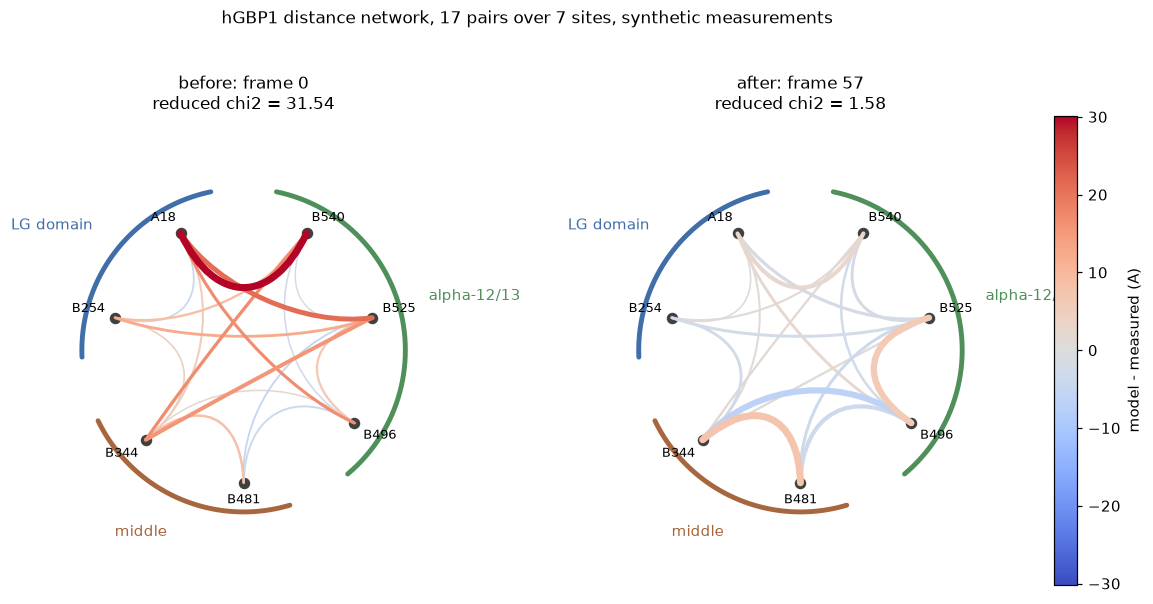

In [11]:
dev_end, sig_end = deviation(d_end), significance(d_end)

VMAX = max(max(abs(v) for v in dev_start.values()),
           max(abs(v) for v in dev_end.values()))
print("colour scale: +-%.0f A, shared by every circle plot below" % VMAX)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.0))
for ax, (dev, sig, name, model) in zip(axes, [
        (dev_start, sig_start, "before: frame 0", d_start),
        (dev_end, sig_end, "after: frame %d" % LAST, d_end)]):
    ws.circle_plot(PAIRS, dev, ax=ax, vmax=VMAX, widths=sig,
                   groups=GROUPS, order=ORDER, label_fmt=site_label, colorbar=False,
                   title="%s\nreduced chi2 = %.2f" % (name, chi2_red(model)))
bar = fig.colorbar(ws.deviation_mappable(VMAX), ax=axes, fraction=0.022, pad=0.02)
bar.set_label("model - measured (A)")
fig.suptitle("hGBP1 distance network, %d pairs over %d sites, synthetic measurements"
             % (len(PAIRS), len(SITES)), y=1.01, fontsize=11)
plt.show()

### What the left panel says

Three things come off it without reading a single number.

**The colour is not spread evenly, and it is not confined to one corner
either.** Every thick red chord has one end in the LG domain or the middle
domain and the other in the alpha-12/13 group. Chords that stay *inside* the
alpha-12/13 arc are pale and thin. That pattern is the signature of two rigid
groups whose relative placement is wrong -- which is exactly what a hinge
motion looks like when you score the wrong end of it.

The converse is not true, and it is worth noticing: B481 is drawn in the middle
group because residue 481 is where the conventional domain boundary is put, but
both of its chords are pale. On this trajectory 481 moves with the helices, not
with the rest of the middle domain. The rim grouping is a hypothesis about what
is rigid, the chord colours are the test of it, and here the test disagrees
with the textbook boundary by one site.

**The sign is uniform among the significant chords.** Ten chords are more than
two standard deviations out and every one of them is positive: frame 0 holds the
helices too far from the GTPase domain. Not one chord is significantly too
short. A model that is merely imprecise has no reason to arrange its errors by
sign and by which arcs they connect. The single reduced chi-squared number says
none of this, and the table yields it only after a minute of arithmetic.

**Some chords are pale in both panels.** The pairs inside alpha-12/13 change by
under two Angstrom between the two states, so the wrong model scores them
within a standard deviation. They are perfectly good measurements and they
carry no information about *this* question. In a real experiment they are the
pairs you stop paying for -- and the pairs you keep as a control, because a
model that gets *those* wrong has a problem that is not conformational.

The right panel is what agreement looks like: pale, thin, no structure. The
residual colour is the 6 per cent noise, nothing more. "No structure" is the
thing to check -- if the right panel were pale everywhere except for three
thick chords on one site, the model would be good and that site would be the
problem.

## How far along the transition do the data actually pin you?

Handing a reader the correct structure is not an analysis. The honest version
of "after" is a model that was *fitted*.

On a two-chain assembly the usual demonstration is a rigid-body fit: let one
chain move against the other and watch chi-squared fall. That fit is not
available here and it would be meaningless if it were, because this is a single
molecule undergoing an internal hinge motion -- there is no second body to
move.

What there is instead is a one-parameter model that is far more honest, and
comes for free: **the frame index**. The trajectory is a path through
conformational space; scoring every frame on it asks "how far along is the
molecule?" and the width of the answer is a real measurement of what seventeen
distances can resolve.

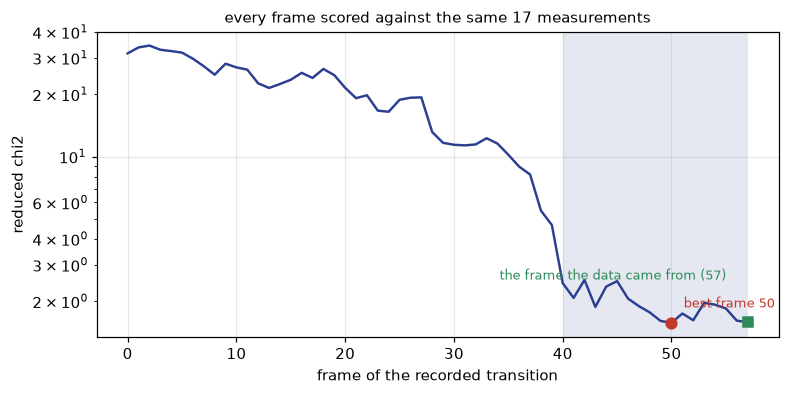

scan of 58 frames in 2.3 s
chi2 at frame  0 :   31.54
chi2 at frame 57 :    1.58   (the frame the data came from)
chi2 at frame 50 :    1.57   (the best frame)
frames within chi2_min + 1: 40 to 57 -- 18 of 58 frames, 31% of the path


In [12]:
t0 = time.time()
chi2_path = np.array([chi2_red(network_of(f, PAIRS)) for f in range(n_frames)])
best = int(np.argmin(chi2_path))
within = np.flatnonzero(chi2_path <= chi2_path[best] + 1.0)

fig, ax = plt.subplots(figsize=(8.0, 3.6))
ax.plot(np.arange(n_frames), chi2_path, color="#2C3E90", lw=1.6)
ax.axvspan(within.min(), within.max(), color="#2C3E90", alpha=0.12, lw=0)
ax.plot([best], [chi2_path[best]], "o", color="#C0392B", ms=7)
ax.plot([TRUTH], [chi2_path[TRUTH]], "s", color="#2E8B57", ms=7)
ax.annotate("best frame %d" % best, (best, chi2_path[best]),
            textcoords="offset points", xytext=(8, 10), fontsize=8.5, color="#C0392B")
ax.annotate("the frame the data came from (%d)" % TRUTH, (TRUTH, chi2_path[TRUTH]),
            textcoords="offset points", xytext=(-14, 28), fontsize=8.5, color="#2E8B57",
            ha="right")
ax.set_yscale("log")
ax.set_xlabel("frame of the recorded transition")
ax.set_ylabel("reduced chi2")
ax.set_title("every frame scored against the same %d measurements" % len(PAIRS), fontsize=10)
plt.show()

print("scan of %d frames in %.1f s" % (n_frames, time.time() - t0))
print("chi2 at frame  0 : %7.2f" % chi2_path[0])
print("chi2 at frame %2d : %7.2f   (the frame the data came from)" % (TRUTH, chi2_path[TRUTH]))
print("chi2 at frame %2d : %7.2f   (the best frame)" % (best, chi2_path[best]))
print("frames within chi2_min + 1: %d to %d -- %d of %d frames, %.0f%% of the path"
      % (within.min(), within.max(), len(within), n_frames, 100 * len(within) / n_frames))

The curve falls by more than an order of magnitude and then flattens. Two
readings, and the second is the one to take away.

**The data reject the wrong end decisively.** Seventeen distances at 6 per cent
put frame 0 tens of standard deviations away from the measurements. No
subtlety is needed for that.

**They do not locate the right end nearly as sharply.** The chi-squared minimum
is a broad basin covering the last stretch of the path, not a point. Reporting
"the data are consistent with the final state" is defensible; reporting a
single frame as *the* answer is reading precision into a flat bottom. This is
the honest version of an error bar on a structural model, and it is the thing
most often missing when a FRET-derived structure is quoted.

Note also that the best frame is not the frame the data came from. The gap is
noise: a different draw moves it by a few frames. Anybody who tunes a model
until the minimum lands on the expected answer is fitting the noise.

## The trap this replaces: a two-state model of a continuous change

The rigid-body version of this section, on a two-chain complex, teaches that a
fit with too few degrees of freedom buys chi-squared by breaking something the
target function does not look at. The single-molecule equivalent is a different
mistake with the same shape, and it is a very common one.

Suppose the molecule is actually in an intermediate state, and your model set
is the two end states, because those are the two structures you have. You score
both, one of them wins, and you report it. Here is what that looks like when
the ground truth is a frame in the middle of the path.

In [13]:
MIDDLE = 29
mid_measured, mid_sigma = synthesise(MIDDLE, 20240917)

mid_chi2 = np.array([chi2_red(network_of(f, PAIRS), mid_measured, mid_sigma)
                     for f in range(n_frames)])
mid_best = int(np.argmin(mid_chi2))
mid_within = np.flatnonzero(mid_chi2 <= mid_chi2[mid_best] + 1.0)

for frame, tag in ((0, "end state"), (LAST, "end state"), (mid_best, "best on the path"),
                   (MIDDLE, "the truth")):
    model = network_of(frame, PAIRS)
    residual = np.array([(model[p] - mid_measured[p]) / mid_sigma[p] for p in PAIRS])
    print("frame %2d (%-16s): chi2 %6.2f   residuals %+5.1f to %+5.1f   %2d of %d beyond 2 sigma"
          % (frame, tag, chi2_red(model, mid_measured, mid_sigma),
             residual.min(), residual.max(), int((np.abs(residual) > 2).sum()), len(PAIRS)))
print()
print("the two-state answer would be frame %d, on a chi2 of %.1f"
      % (0 if mid_chi2[0] < mid_chi2[LAST] else LAST, min(mid_chi2[0], mid_chi2[LAST])))
print("the path minimum is frame %d (chi2 %.2f), pinned to frames %d-%d"
      % (mid_best, mid_chi2[mid_best], mid_within.min(), mid_within.max()))

frame  0 (end state       ): chi2  12.98   residuals  -2.6 to +10.2    8 of 17 beyond 2 sigma
frame 57 (end state       ): chi2   7.71   residuals  -5.5 to  +4.9    9 of 17 beyond 2 sigma
frame 29 (best on the path): chi2   1.58   residuals  -2.3 to  +2.7    3 of 17 beyond 2 sigma
frame 29 (the truth       ): chi2   1.58   residuals  -2.3 to  +2.7    3 of 17 beyond 2 sigma

the two-state answer would be frame 57, on a chi2 of 7.7
the path minimum is frame 29 (chi2 1.58), pinned to frames 24-32


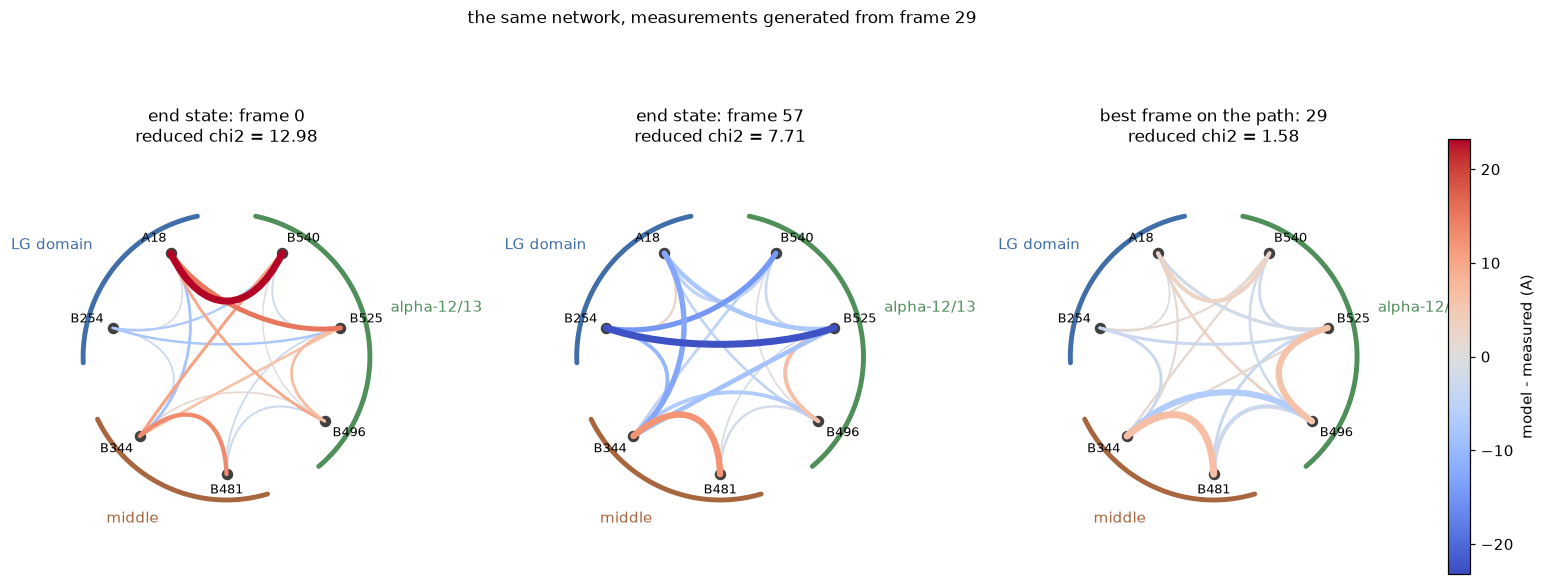

In [14]:
mid_models = [(0, "end state: frame 0"), (LAST, "end state: frame %d" % LAST),
              (mid_best, "best frame on the path: %d" % mid_best)]
mid_dev = {f: deviation(network_of(f, PAIRS), mid_measured) for f, _ in mid_models}
MID_VMAX = max(abs(v) for dev in mid_dev.values() for v in dev.values())

fig, axes = plt.subplots(1, 3, figsize=(17.0, 6.0))
for ax, (frame, name) in zip(axes, mid_models):
    model = network_of(frame, PAIRS)
    ws.circle_plot(PAIRS, mid_dev[frame], ax=ax, vmax=MID_VMAX,
                   widths=significance(model, mid_measured, mid_sigma),
                   groups=GROUPS, order=ORDER, label_fmt=site_label, colorbar=False,
                   title="%s\nreduced chi2 = %.2f"
                         % (name, chi2_red(model, mid_measured, mid_sigma)))
bar = fig.colorbar(ws.deviation_mappable(MID_VMAX), ax=axes, fraction=0.015, pad=0.02)
bar.set_label("model - measured (A)")
fig.suptitle("the same network, measurements generated from frame %d" % MIDDLE,
             y=1.02, fontsize=11)
plt.show()

The two left-hand panels are the useful ones, and they are useful because of
what they have in common.

Each of them is wrong, and they are wrong *in opposite directions*. Frame 0 is
significantly too long on seven chords and too short on one; frame 57 is
significantly too short on seven and too long on two. The truth is between them,
and the two panels say so by disagreeing with the same data with opposite signs.

That is the fingerprint of a model set that is missing a degree of freedom the
data want. Neither end state can be pushed towards the intermediate by moving
anything, because neither is a rotation or a translation away from it -- the
molecule is partway through an internal hinge, and an end state is the wrong
shape, not the wrong placement. Notice too that both panels carry chords of
both signs, spread across the rim rather than concentrated on one arc, which is
what separates this from the clean two-group pattern of the previous section.

Compare that with the right-hand panel, where the missing parameter has been
supplied. The residual collapses to the noise floor, and the colour that
remains has no pattern.

That is the pattern to learn, and it is the same one the rigid-body version of
this exercise teaches:

* A residual that is **spread and two-signed** after a fit means the model is
  missing a degree of freedom the data want, not that the data are bad.
* A residual that is **concentrated** after a fit means one part of the model,
  or one part of the data, is wrong on its own.

And note the trap in the numbers. Scoring only the two ends gives one of them a
visibly better chi-squared than the other, and nothing in that comparison says
that both are wrong. The winner of a comparison between two bad models is a bad
model. Only scoring a *continuum* -- which here costs eight seconds -- shows the
basin sitting nowhere near either end.

## The companion figure the circle cannot replace

The circle plot throws away one thing: the distances themselves. Every chord is
coloured by a deviation, so a 2 A error on a 35 A pair and a 2 A error on a
75 A pair look identical, and you cannot see from the circle that the second one
is a much easier measurement in relative terms and a much harder one in
absolute terms, because transfer efficiency is flat out there.

So the circle plot always travels with a scatter: measured against modelled, one
point per pair, with the experimental error bar drawn. The identity line is the
perfect model. This is the view that tells you the range of the network,
whether the disagreement grows with distance -- which would point at the
Forster radius or at the efficiency calibration rather than at the structure --
and whether the error bars are honest.

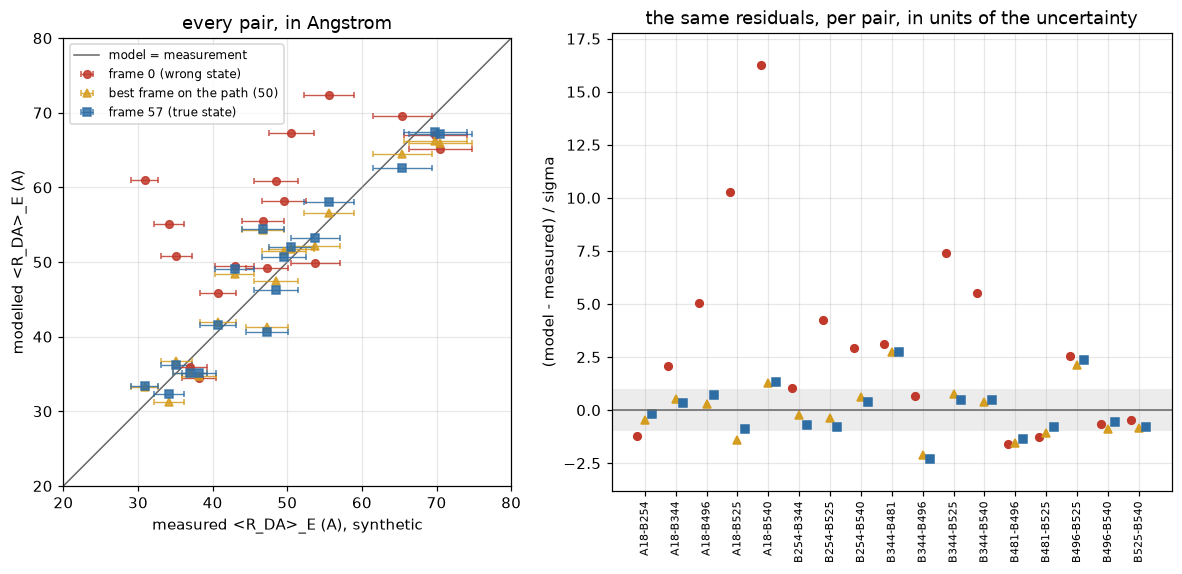

root-mean-square deviation over the network, in A:
  frame 0 (wrong state)            12.4
  best frame on the path (50)       3.4
  frame 57 (true state)             3.5


In [15]:
d_best = network_of(best, PAIRS)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4),
                         gridspec_kw={"width_ratios": [1.0, 1.25]})

ax = axes[0]
x = np.array([measured[p] for p in PAIRS])
xerr = np.array([sigma[p] for p in PAIRS])
series = [("frame 0 (wrong state)", d_start, "#c0392b", "o"),
          ("best frame on the path (%d)" % best, d_best, "#d59d20", "^"),
          ("frame %d (true state)" % LAST, d_end, "#2e6da4", "s")]
span = [20, 80]
ax.plot(span, span, "-", color="0.4", lw=1.0, zorder=0, label="model = measurement")
for name, model, colour, marker in series:
    y = np.array([model[p] for p in PAIRS])
    ax.errorbar(x, y, xerr=xerr, fmt=marker, ms=5, color=colour, ecolor=colour,
                elinewidth=0.9, capsize=2, alpha=0.85, ls="none", label=name)
ax.set_xlim(*span); ax.set_ylim(*span); ax.set_aspect("equal")
ax.set_xlabel("measured <R_DA>_E (A), synthetic")
ax.set_ylabel("modelled <R_DA>_E (A)")
ax.set_title("every pair, in Angstrom")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
names = ["%s-%s" % (site_label(p[0]), site_label(p[1])) for p in PAIRS]
idx = np.arange(len(PAIRS))
for offset, (name, model, colour, marker) in zip((-0.24, 0.0, 0.24), series):
    r = np.array([(model[p] - measured[p]) / sigma[p] for p in PAIRS])
    ax.plot(idx + offset, r, marker, ms=5, color=colour, ls="none", label=name)
ax.axhline(0, color="0.4", lw=1.0)
ax.axhspan(-1, 1, color="0.5", alpha=0.15, lw=0)
ax.set_xticks(idx); ax.set_xticklabels(names, rotation=90, fontsize=7.5)
ax.set_ylabel("(model - measured) / sigma")
ax.set_title("the same residuals, per pair, in units of the uncertainty")
ax.margins(y=0.08)   # the left panel's legend serves both
plt.show()

print("root-mean-square deviation over the network, in A:")
for name, model, _, _ in series:
    r = np.array([model[p] - measured[p] for p in PAIRS])
    print("  %-30s %6.1f" % (name, np.sqrt((r ** 2).mean())))

The grey band in the right-hand panel is one standard deviation. A model that
fits sits inside it about two thirds of the time and strays outside the rest --
that is what the blue squares do, and it is the whole content of the statement
"reduced chi2 is about 1.5". The red circles reach sixteen standard deviations,
and those are the chords the circle plot drew thickest.

The left panel adds something the circle plot genuinely cannot show: how the
disagreement behaves as a function of distance. Here the error bars widen in
proportion to the distance, which is what a flat 6 per cent uncertainty looks
like and is true here only because that is how the data were generated. In a
real network this panel is where you check that claim. Points that fan out
faster than their bars mean the far pairs are less reliable than the quoted
errors say, and every chi-squared computed from that network is then wrong.
Points that drift consistently to one side of the line at long distance, but
not at short, usually mean the Forster radius is off rather than the structure.

Notice also that every red point that is significantly off sits *above* the
line -- ten of them, and none significantly below. A whole-network offset with a
consistent sign is the signature of a state error, and in the circle it appeared
as red chords all running between the same two arcs. Two views, one fact -- but
only the circle told you *which* chords.

Both panels are the same seventeen numbers as the circle. The scatter is better
at magnitudes and at spotting a trend with distance. The circle is better at
*where*, and "where" is the question that changes what you do next.

## What to look for when the data are real

With a real network and a real model, three patterns in the circle plot mean
three different things, and telling them apart is most of the skill.

**Colour everywhere, no pattern in the sign.** The model is the wrong
conformation, or -- as the intermediate-state section showed -- no single
structure in your set is the right one, or the sample is a mixture of
conformations and no single structure *can* satisfy the network. Check the
efficiency histograms for two populations before you touch the structure.

**Colour concentrated on the chords that cross one domain boundary, with a
consistent sign.** The domains are individually right and their relative
placement is wrong. This is the case a structural refinement is actually good
at, and the chords that stay pale tell you which parts of the model to hold
fixed while you refine. The "before" panel in this notebook is a clean example:
every significant chord crosses from the GTPase end to the helical end, and the
chords within each end are pale.

**Several bad chords, all touching one site, with the rest of the circle
pale.** This is almost never the model. A site whose every chord is off in the
same direction is a site whose dye is not behaving: stuck to the surface so its
mean position is pulled towards the protein and every distance from it comes
out short, or pushed out by a bad linker so every distance comes out long, or
simply mislabelled in the spreadsheet. The circle plot makes this diagnosis
easy, because a genuine structural error has no reason to respect the site
boundaries the way a labelling error does, and the rim ordering puts all of one
site's chords next to each other.

The practical consequence: when one site is the culprit, the fix is to redo
that site's controls -- anisotropy, the quantum yield, the accessible volume
parameters for that linker -- not to add a restraint or loosen the model. Drop
the site from the network, refit, and see whether the rest of the circle was
ever really in disagreement. If it snaps into place, you had a labelling
problem wearing a structural problem's clothes.

Two last things the figures here cannot show, because the data are synthetic.

In a real network the uncertainty is not 6 per cent of every distance. The
published hGBP1 file this notebook opened quotes errors from +-2 A to +-51 A on
the same molecule, because some pairs sit near R0 where efficiency is steep and
informative and others sit far out where it is flat. That is precisely why the
chord thickness carries sigma rather than Angstrom: on real data the circle
plot's thick chords are frequently not its most colourful ones.

And a real network has to be matched to a real topology. The first section of
this notebook is the whole lesson in miniature. Two lists of distances with the
same residue numbers on them are not comparable until somebody has checked that
the numbers mean the same thing, and a chi-squared will never tell you that
they do not.

In [16]:
print("notebook runtime: %.0f s" % (time.time() - t_start))

notebook runtime: 15 s
